# Automated Barcoding Detection

Note to self: scriptify the manual line segment extraction, which may be useful

E2E file
→ select B-scan
→ obtain BM boundary
→ flatten to BM
→ crop fixed depth below BM
→ normalize ROI
→ return arrays + metadata

## E2E Prep, Flattening, and Cropping

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "src").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not locate the project root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.barcode.data import (
    inspect_volume_layers,
    load_e2e_volume,
    preprocess_bscan,
)

In [2]:
E2E_PATH = PROJECT_ROOT / "data" / "heyex" / "meta" / "ea8.E2E"

volume = load_e2e_volume(E2E_PATH)

print("Volume type:", type(volume))
print("Volume shape:", volume.shape)
print("Available layers:", inspect_volume_layers(volume))

Volume type: <class 'eyepy.core.eyevolume.EyeVolume'>
Volume shape: (97, 496, 512)
Available layers: ['ILM', 'BM', 'RNFL', 'GCL', 'IPL', 'INL', 'OPL', 'ELM', 'PR1', 'PR2', 'RPE']


In [3]:
# Select initial BScan
BSCAN_INDEX = 41

bscan = volume[BSCAN_INDEX]

print("B-scan index:", BSCAN_INDEX)
print("B-scan shape:", bscan.shape)
print("Metadata:", bscan.meta)

B-scan index: 41
B-scan shape: (496, 512)
Metadata: start_pos: (-9.799324989318848, 0.9622939825057983)
end_pos: (10.2138090133667, 1.605315089225769)
pos_unit: °
unknown0: 23
size_y: 496
size_x: 512
start_x: -9.799324989318848
start_y: 0.9622939825057983
end_x: 10.2138090133667
end_y: 1.605315089225769
zero1: 0
unknown1: 66557856.0
scale_y: 0.0038716699928045273
unknown2: 1.0
zero2: 0
unknown3: ListContainer: 
    5987.3955078125
    116.47171783447266
zero3: 0
imgSizeWidth: 512
n_bscans: 97
aktImage: 41
scan_pattern: 1
center_x: 0.20724201202392578
center_y: 1.2838045358657837
unknown4: 1
acquisitionTime: 2024-02-16T23:22:36.250999
numAve: 0
quality: 0.8416000008583069
unknown5: 0.9146999716758728


In [4]:
processed = preprocess_bscan(
    volume=volume,
    bscan_index=41,
    bm_layer_name="BM",
    depth_below_bm=150,
)

print("Raw shape:", processed.raw_bscan.shape)
print("BM boundary shape:", processed.bm_boundary.shape)
print("Flattened shape:", processed.flattened_bscan.shape)
print("Sub-BM crop shape:", processed.sub_bm_crop.shape)
print("Reference row:", processed.reference_row)

Raw shape: (496, 512)
BM boundary shape: (512,)
Flattened shape: (496, 512)
Sub-BM crop shape: (150, 512)
Reference row: 253


In [5]:
print("BM minimum row:", processed.bm_boundary.min())
print("BM maximum row:", processed.bm_boundary.max())
print("BM median row:", np.median(processed.bm_boundary))
print("First 10 coordinates:", processed.bm_boundary[:10])

BM minimum row: 215.13289
BM maximum row: 273.66016
BM median row: 252.8485
First 10 coordinates: [220.51967 220.88426 221.2488  221.61324 221.97752 222.34163 222.70554
 223.06929 223.43295 223.79666]


In [6]:
bm_layer = volume.layers["BM"]

print("Type:", type(bm_layer))
print("Attributes:", [name for name in dir(bm_layer) if not name.startswith("_")])

if hasattr(bm_layer, "data"):
    print("Data type:", type(bm_layer.data))
    print("Data shape:", np.asarray(bm_layer.data).shape)

Type: <class 'eyepy.core.annotations.EyeVolumeLayerAnnotation'>
Attributes: ['data', 'knots', 'layer_indices', 'meta', 'name', 'volume']
Data type: <class 'numpy.ndarray'>
Data shape: (97, 512)


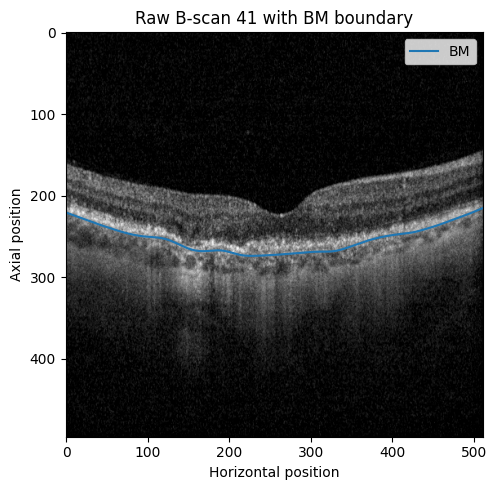

In [7]:
# Raw Scan with BM overley
plt.figure(figsize=(12, 5))

plt.imshow(
    processed.raw_bscan,
    cmap="gray",
)

plt.plot(
    np.arange(processed.bm_boundary.size),
    processed.bm_boundary,
    linewidth=1.5,
    label="BM",
)

plt.title(f"Raw B-scan {processed.bscan_index} with BM boundary")
plt.xlabel("Horizontal position")
plt.ylabel("Axial position")
plt.legend()
plt.tight_layout()
plt.show()

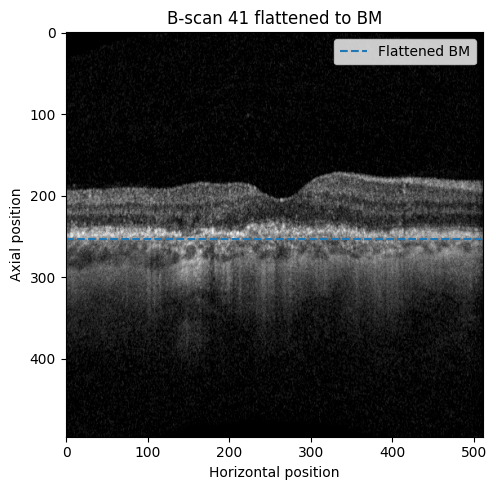

In [8]:
# Flattened scan
plt.figure(figsize=(12, 5))

plt.imshow(
    processed.flattened_bscan,
    cmap="gray",
)

plt.axhline(
    processed.reference_row,
    linestyle="--",
    linewidth=1.5,
    label="Flattened BM",
)

plt.title(f"B-scan {processed.bscan_index} flattened to BM")
plt.xlabel("Horizontal position")
plt.ylabel("Axial position")
plt.legend()
plt.tight_layout()
plt.show()

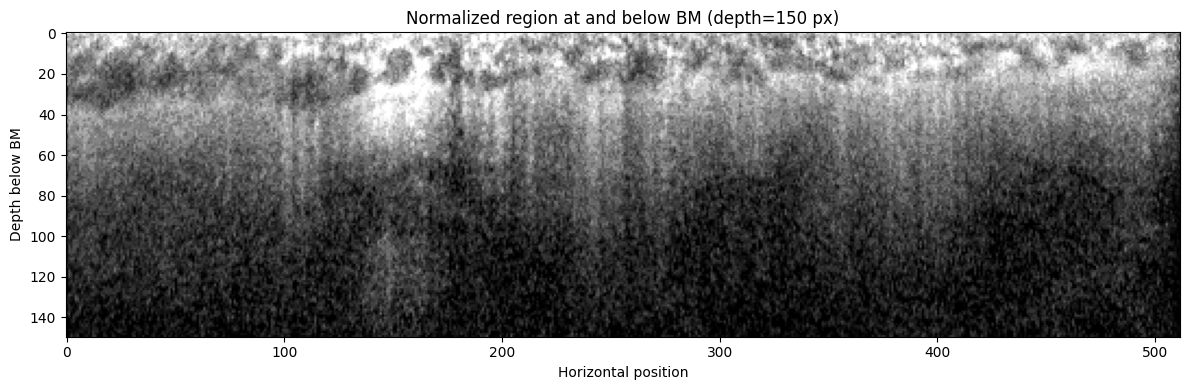

In [9]:
# Region below BM
plt.figure(figsize=(12, 4))

plt.imshow(
    processed.normalized_crop,
    cmap="gray",
    aspect="auto",
)

plt.title(
    f"Normalized region at and below BM "
    f"(depth={processed.depth_below_bm} px)"
)
plt.xlabel("Horizontal position")
plt.ylabel("Depth below BM")
plt.tight_layout()
plt.show()

I actually suspect vertical persistence is going to end up being the key feature rather than brightness. The human eye is picking up those long, coherent bright columns—not just bright spots—and our algorithm should try to quantify exactly that. That also aligns well with the paper you’re using as inspiration: reduce the OCT to a robust 1D signal along the horizontal axis, segment contiguous abnormal regions, and then perform all measurements within those detected intervals.

## Model and Training


In [19]:
import importlib
import src.barcode.model_threshold as threshold_module

importlib.reload(threshold_module)

from src.barcode.model_threshold import ThresholdBarcodeDetector

In [20]:
detector = ThresholdBarcodeDetector(
    bright_quantile=0.75,
    smooth_sigma=4.0,
    min_interval_length=12,
    max_gap=6,
    threshold_multiplier=1.0,
)

prediction = detector.predict(roi)

print(f"Threshold: {prediction.threshold:.4f}")
print(f"Detected intervals: {len(prediction.intervals)}")

for interval in prediction.intervals:
    print(
        f"x={interval.x_start:3d} to {interval.x_end:3d} | "
        f"length={interval.length_px:3d} px | "
        f"mean score={interval.mean_score:.4f} | "
        f"max score={interval.max_score:.4f}"
    )

Threshold: 0.1784
Detected intervals: 5
x=132 to 172 | length= 41 px | mean score=0.3030 | max score=0.3500
x=216 to 252 | length= 37 px | mean score=0.2013 | max score=0.2362
x=273 to 294 | length= 22 px | mean score=0.1950 | max score=0.2042
x=362 to 407 | length= 46 px | mean score=0.2276 | max score=0.2437
x=431 to 443 | length= 13 px | mean score=0.1926 | max score=0.2015


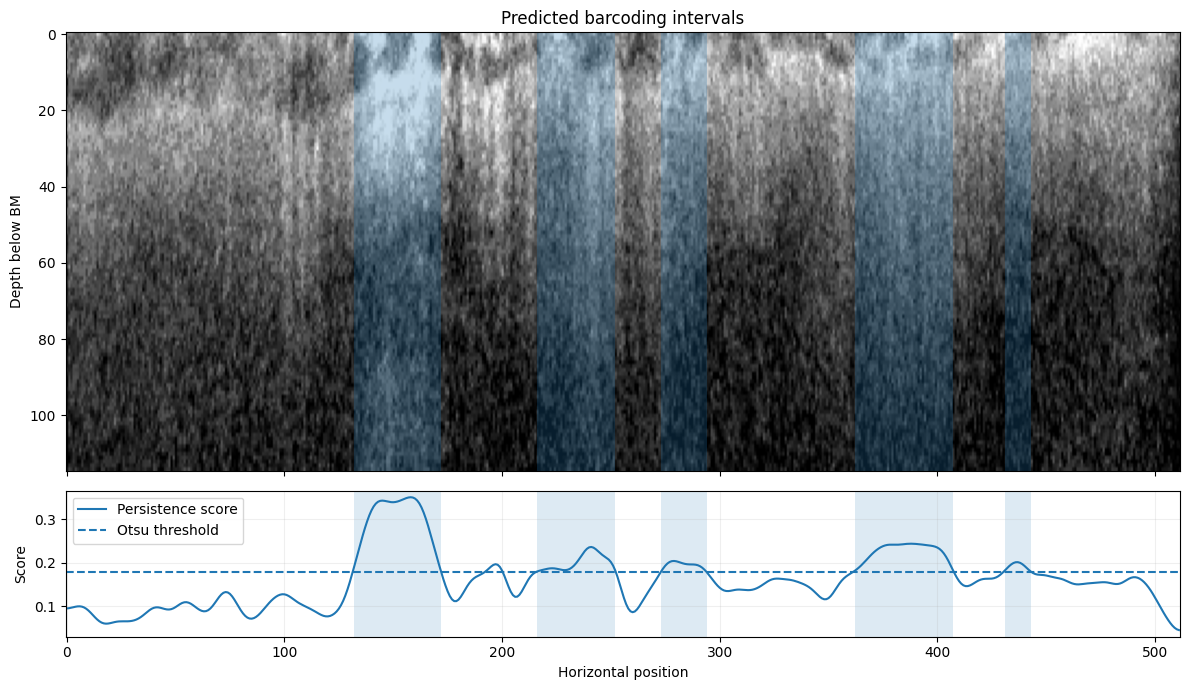

In [21]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 7),
    sharex=True,
    gridspec_kw={
        "height_ratios": [3, 1],
    },
)

axes[0].imshow(
    roi,
    cmap="gray",
    aspect="auto",
)

for interval in prediction.intervals:
    axes[0].axvspan(
        interval.x_start,
        interval.x_end,
        alpha=0.25,
    )

axes[0].set_title("Predicted barcoding intervals")
axes[0].set_ylabel("Depth below BM")

axes[1].plot(
    prediction.smoothed_signal,
    label="Persistence score",
)

axes[1].axhline(
    prediction.threshold,
    linestyle="--",
    label="Otsu threshold",
)

for interval in prediction.intervals:
    axes[1].axvspan(
        interval.x_start,
        interval.x_end,
        alpha=0.15,
    )

axes[1].set_xlabel("Horizontal position")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

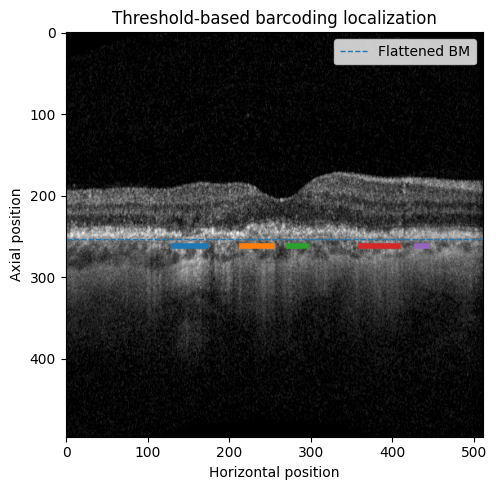

In [22]:
plt.figure(figsize=(12, 5))

plt.imshow(
    processed.flattened_bscan,
    cmap="gray",
)

overlay_y = processed.reference_row + 8

for interval in prediction.intervals:
    plt.plot(
        [interval.x_start, interval.x_end],
        [overlay_y, overlay_y],
        linewidth=4,
    )

plt.axhline(
    processed.reference_row,
    linestyle="--",
    linewidth=1,
    label="Flattened BM",
)

plt.title("Threshold-based barcoding localization")
plt.xlabel("Horizontal position")
plt.ylabel("Axial position")
plt.legend()
plt.tight_layout()
plt.show()

This result tells us something important: vertical persistence alone is detecting hypertransmission broadly, not barcoding specifically.

The strongest interval at x=132–172 is clearly distinct, but the other four intervals are weaker areas of persistent brightness. To isolate barcoding, we now need the second defining property: alternating brightness across neighboring columns.

So the next step is to combine:
$$
\text{barcode score}
=
\text{vertical persistence}
\times
\text{horizontal oscillation}
$$

We compute horizontal oscillation using a 90th percentile intensity profile. The broad gaussian captures gradual illumination changes. Subtracting it leaves rapid bright–dark alternation across adjacent columns

In [ ]:
detector = ThresholdBarcodeDetector(
    bright_quantile=0.75,
    smooth_sigma=4.0,
    min_interval_length=12,
    max_gap=6,
    threshold_multiplier=1.0,
)

prediction = detector.predict(roi)

candidate_intervals = prediction.intervals

print(f"Threshold: {prediction.threshold:.4f}")
print(f"Candidate intervals: {len(candidate_intervals)}")

for interval in candidate_intervals:
    print(
        f"x={interval.x_start:3d} to {interval.x_end:3d} | "
        f"length={interval.length_px:3d} px | "
        f"mean score={interval.mean_score:.4f} | "
        f"max score={interval.max_score:.4f}"
    )

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

# --------------------------------------------------
# Top panel: candidate intervals on the ROI
# --------------------------------------------------

axes[0].imshow(
    roi,
    cmap="gray",
    aspect="auto",
)

colors = plt.cm.tab10.colors

for i, interval in enumerate(candidate_intervals):

    color = colors[i % len(colors)]

    axes[0].axvspan(
        interval.x_start,
        interval.x_end,
        color=color,
        alpha=0.25,
    )

    axes[0].text(
        (interval.x_start + interval.x_end) / 2,
        8,
        str(i + 1),
        color="white",
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="center",
    )

axes[0].set_title(
    "Persistence-based candidate barcoding intervals"
)
axes[0].set_ylabel("Depth below BM")

# --------------------------------------------------
# Bottom panel: persistence signal
# --------------------------------------------------

axes[1].plot(
    prediction.smoothed_signal,
    linewidth=2,
    label="Persistence score",
)

axes[1].axhline(
    prediction.threshold,
    linestyle="--",
    color="tab:red",
    label="Otsu threshold",
)

for i, interval in enumerate(candidate_intervals):

    color = colors[i % len(colors)]

    axes[1].axvspan(
        interval.x_start,
        interval.x_end,
        color=color,
        alpha=0.15,
    )

axes[1].set_xlabel("Horizontal position")
axes[1].set_ylabel("Score")
axes[1].grid(alpha=0.2)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
column_signal = np.quantile(
    roi,
    0.90,
    axis=0,
)

broad_baseline = gaussian_filter1d(
    column_signal,
    sigma=20,
)

high_frequency_signal = (
    column_signal - broad_baseline
)

oscillation_score = np.sqrt(
    gaussian_filter1d(
        high_frequency_signal ** 2,
        sigma=4,
    )
)

In [ ]:
persistence_normalized = minmax_scale(
    prediction.smoothed_signal
)

oscillation_normalized = minmax_scale(
    oscillation_score
)

composite_score = gaussian_filter1d(
    persistence_normalized
    * oscillation_normalized,
    sigma=2,
)

In [ ]:
import pandas as pd
import numpy as np


def summarize_candidate_intervals(
    intervals,
    persistence_signal,
    oscillation_signal,
    composite_signal,
    intensity_signal,
):
    """
    Summarize each candidate interval with descriptive features.
    """

    rows = []

    for idx, interval in enumerate(intervals):

        start = interval.x_start
        end = interval.x_end + 1

        p = persistence_signal[start:end]
        o = oscillation_signal[start:end]
        c = composite_signal[start:end]
        i = intensity_signal[start:end]

        rows.append(
            {
                "candidate": idx + 1,
                "x_start": start,
                "x_end": interval.x_end,
                "length_px": interval.length_px,

                "persistence_mean": np.mean(p),
                "persistence_max": np.max(p),

                "oscillation_mean": np.mean(o),
                "oscillation_max": np.max(o),

                "composite_mean": np.mean(c),
                "composite_max": np.max(c),

                "intensity_mean": np.mean(i),
                "intensity_max": np.max(i),
            }
        )

    return pd.DataFrame(rows)

In [ ]:
candidate_df = summarize_candidate_intervals(
    intervals=candidate_intervals,
    persistence_signal=persistence_normalized,
    oscillation_signal=oscillation_normalized,
    composite_signal=composite_score,
    intensity_signal=column_signal,
)

candidate_df.round(4)

## Evaluation


## Measurement Extraction